<a href="https://colab.research.google.com/github/bberrium/Picsart-Academy/blob/main/Phase%203/DL/notebooks/Anahit_Mkrtumyan_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2: Convolutional Neural Networks on CIFAR-10

**Goal:** Build a CNN that reaches **at least 75% test accuracy** on CIFAR-10.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)


Using device: cuda:0


In [2]:
torchvision.datasets.CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"

# Standard CIFAR-10 normalization stats
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

# Augmented transforms used for training
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),       # padding preserves size after crop
    transforms.RandomHorizontalFlip(),          # 50% chance to flip
    transforms.RandomRotation(10),              # slight rotation
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                           shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Train samples: {len(trainset)} | Test samples: {len(testset)}")


100%|██████████| 170M/170M [00:26<00:00, 6.42MB/s]


Train samples: 50000 | Test samples: 10000


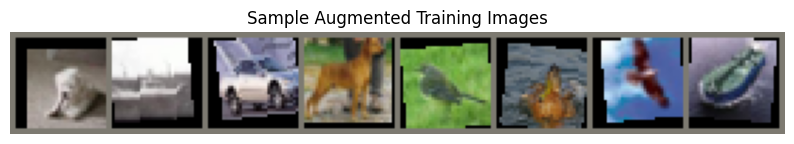

In [10]:
mean = torch.tensor(stats[0]).view(3, 1, 1)
std = torch.tensor(stats[1]).view(3, 1, 1)

def imshow(img, title=None):
    img = img * std + mean  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 4))
imshow(torchvision.utils.make_grid(images[:8]), title="Sample Augmented Training Images")
plt.show()


In [4]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),

            # Block 2: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.3),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = DeepCNN().to(device)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {num_params:,}")


DeepCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [5]:
def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses = []
    test_accs = []
    best_acc = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        test_accs.append(epoch_acc)
        best_acc = max(best_acc, epoch_acc)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} | Test Acc: {epoch_acc:.2f}% | LR: {scheduler.get_last_lr()[0]:.5f}")

    print(f"\nTraining finished in {time.time() - start_time:.2f}s")
    print(f"Best test accuracy: {best_acc:.2f}%")
    return train_losses, test_accs, best_acc


In [6]:
model = DeepCNN().to(device)
train_losses, test_accs, best_acc = train_model(model, trainloader, testloader, epochs=30, lr=0.001)


Epoch [1/30] Loss: 1.7895 | Test Acc: 48.52% | LR: 0.00100
Epoch [2/30] Loss: 1.3827 | Test Acc: 49.85% | LR: 0.00099
Epoch [3/30] Loss: 1.1967 | Test Acc: 59.95% | LR: 0.00098
Epoch [4/30] Loss: 1.0822 | Test Acc: 69.33% | LR: 0.00096
Epoch [5/30] Loss: 1.0052 | Test Acc: 70.80% | LR: 0.00093
Epoch [6/30] Loss: 0.9241 | Test Acc: 75.15% | LR: 0.00090
Epoch [7/30] Loss: 0.8619 | Test Acc: 73.64% | LR: 0.00087
Epoch [8/30] Loss: 0.8107 | Test Acc: 76.48% | LR: 0.00083
Epoch [9/30] Loss: 0.7563 | Test Acc: 78.03% | LR: 0.00079
Epoch [10/30] Loss: 0.7117 | Test Acc: 76.99% | LR: 0.00075
Epoch [11/30] Loss: 0.6778 | Test Acc: 81.65% | LR: 0.00070
Epoch [12/30] Loss: 0.6369 | Test Acc: 82.92% | LR: 0.00065
Epoch [13/30] Loss: 0.6093 | Test Acc: 83.60% | LR: 0.00060
Epoch [14/30] Loss: 0.5744 | Test Acc: 84.01% | LR: 0.00055
Epoch [15/30] Loss: 0.5509 | Test Acc: 84.29% | LR: 0.00050
Epoch [16/30] Loss: 0.5225 | Test Acc: 81.99% | LR: 0.00045
Epoch [17/30] Loss: 0.4979 | Test Acc: 86.44% | L

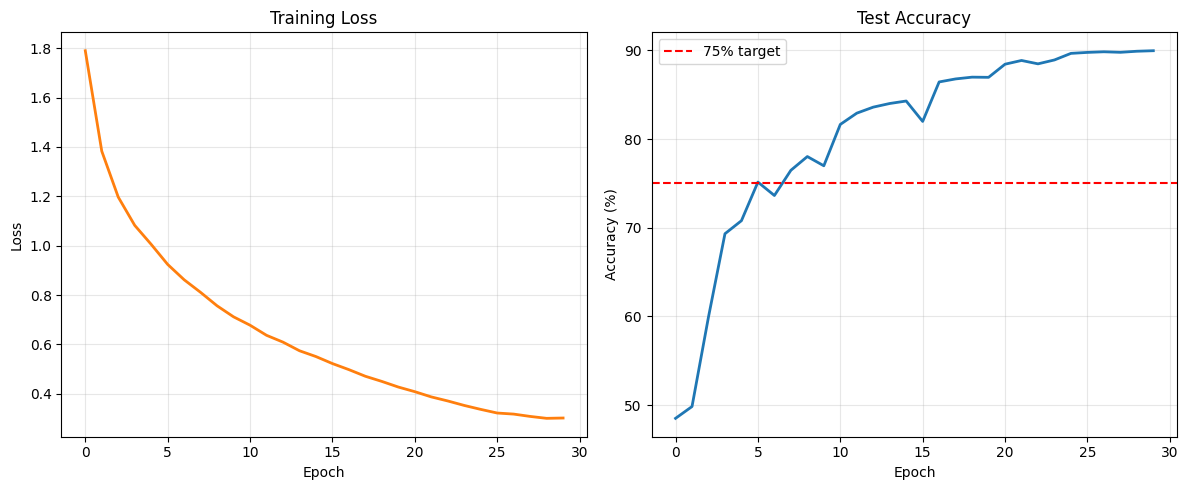

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, linewidth=2, color='tab:orange')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_accs, linewidth=2, color='tab:blue')
plt.axhline(y=75, color='red', linestyle='--', label='75% target')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
model.eval()
correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for label, pred in zip(labels, predicted):
            class_correct[label.item()] += int(label == pred)
            class_total[label.item()] += 1

final_acc = 100 * correct / total
print(f"Final Test Accuracy: {final_acc:.2f}%")
print(f"Best Test Accuracy during training: {best_acc:.2f}%")
print("\nPer-class accuracy:")
for i, c in enumerate(classes):
    print(f"  {c:>6}: {100 * class_correct[i] / class_total[i]:.2f}%")

assert final_acc >= 75 or best_acc >= 75, "Target of 75% accuracy not reached — consider training for more epochs."


Final Test Accuracy: 89.96%
Best Test Accuracy during training: 89.96%

Per-class accuracy:
   plane: 90.70%
     car: 96.10%
    bird: 85.50%
     cat: 73.80%
    deer: 91.40%
     dog: 84.70%
    frog: 95.10%
   horse: 93.20%
    ship: 94.80%
   truck: 94.30%


Total mistakes on test set: 1004 out of 10000 images


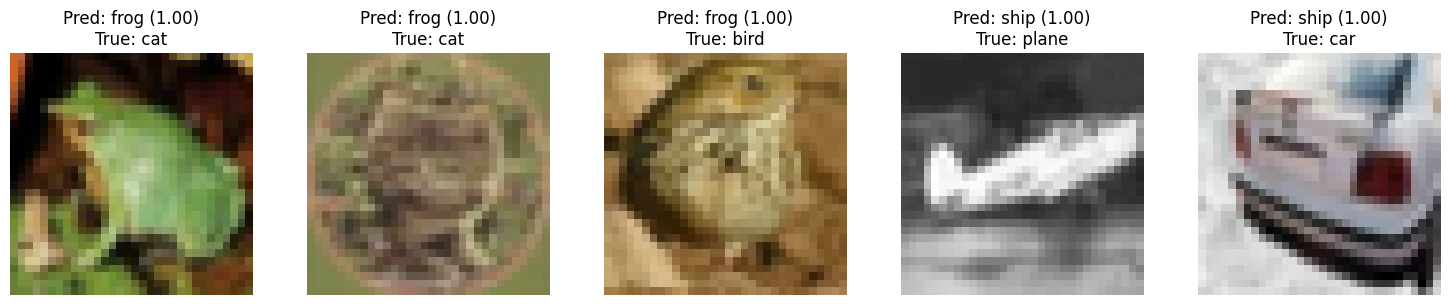

In [11]:
import torch.nn.functional as F

model.eval()
mistakes = []  # list of (confidence, image_tensor, predicted_label, true_label)

with torch.no_grad():
    for images, labels in testloader:
        images_dev, labels_dev = images.to(device), labels.to(device)

        outputs = model(images_dev)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)

        wrong_mask = preds != labels_dev
        wrong_idx = wrong_mask.nonzero(as_tuple=True)[0]

        for idx in wrong_idx:
            mistakes.append((
                confidences[idx].item(),
                images[idx].cpu(),          # keep the original (un-normalized-in-place) CPU tensor
                preds[idx].item(),
                labels[idx].item(),
            ))

# Sort by confidence, highest (most confidently wrong) first
mistakes.sort(key=lambda x: x[0], reverse=True)

print(f"Total mistakes on test set: {len(mistakes)} out of {len(testset)} images")

# Plot the top 5 most confidently incorrect predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    conf, img, pred, true = mistakes[i]
    img = img*std + mean
    img = img.clamp(0, 1)
    npimg = img.numpy()
    axes[i].imshow(np.transpose(npimg, (1, 2, 0)))
    axes[i].set_title(f"Pred: {classes[pred]} ({conf:.2f})\nTrue: {classes[true]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
